# Insights — couche **Gold**

Ce notebook ne contient **que** les analyses. Il lit exclusivement le **silver**
(`datalake/silver/trips`, `silver/zones`, `silver/weather_hourly`) produit par le pipeline :

```bash
make all        # bronze -> silver -> vérifications -> exécute ce notebook
```

Aucune table gold matérialisée n'est nécessaire pour ces agrégats légers (partition pruning +
agrégations pushdown côté Spark) ; si l'un de ces indicateurs devait alimenter un dashboard,
il suffirait d'ajouter `.write.parquet("datalake/gold/<table>")` à la requête concernée.

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while root != root.parent and not (root / "pipelines").exists():
    root = root.parent
sys.path.insert(0, str(root))

from pipelines.config import get_spark, SILVER
from pyspark.sql import functions as F

spark = get_spark("insights-gold")
spark.read.parquet(str(SILVER / "trips")).createOrReplaceTempView("trips")
spark.read.parquet(str(SILVER / "ref" / "zones.parquet")).createOrReplaceTempView("zones")
spark.read.parquet(str(SILVER / "weather_hourly")).createOrReplaceTempView("weather_hourly")

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("Spark", spark.version)
spark.sql("SELECT vtype, year, count(*) AS courses FROM trips GROUP BY 1, 2 ORDER BY 1, 2").show()

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark 4.2.0


+------+----+---------+
| vtype|year|  courses|
+------+----+---------+
|   fhv|2016|132114055|
| green|2016| 16351650|
|yellow|2009|170649434|
|yellow|2016|131070475|
+------+----+---------+



## 1. Évolution des suppléments tarifaires

Montant moyen par course et par type de véhicule. Les courbes qui « démarrent » en cours de
période matérialisent les colonnes apparues progressivement dans le schéma : grâce aux règles
silver (NULL conservé + flag `_applicable`), un trou signifie *« n'existait pas encore »* et non
*« égal à zéro »*.

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


C:\Users\soufp\AppData\Local\Temp\ipykernel_29440\1187079161.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


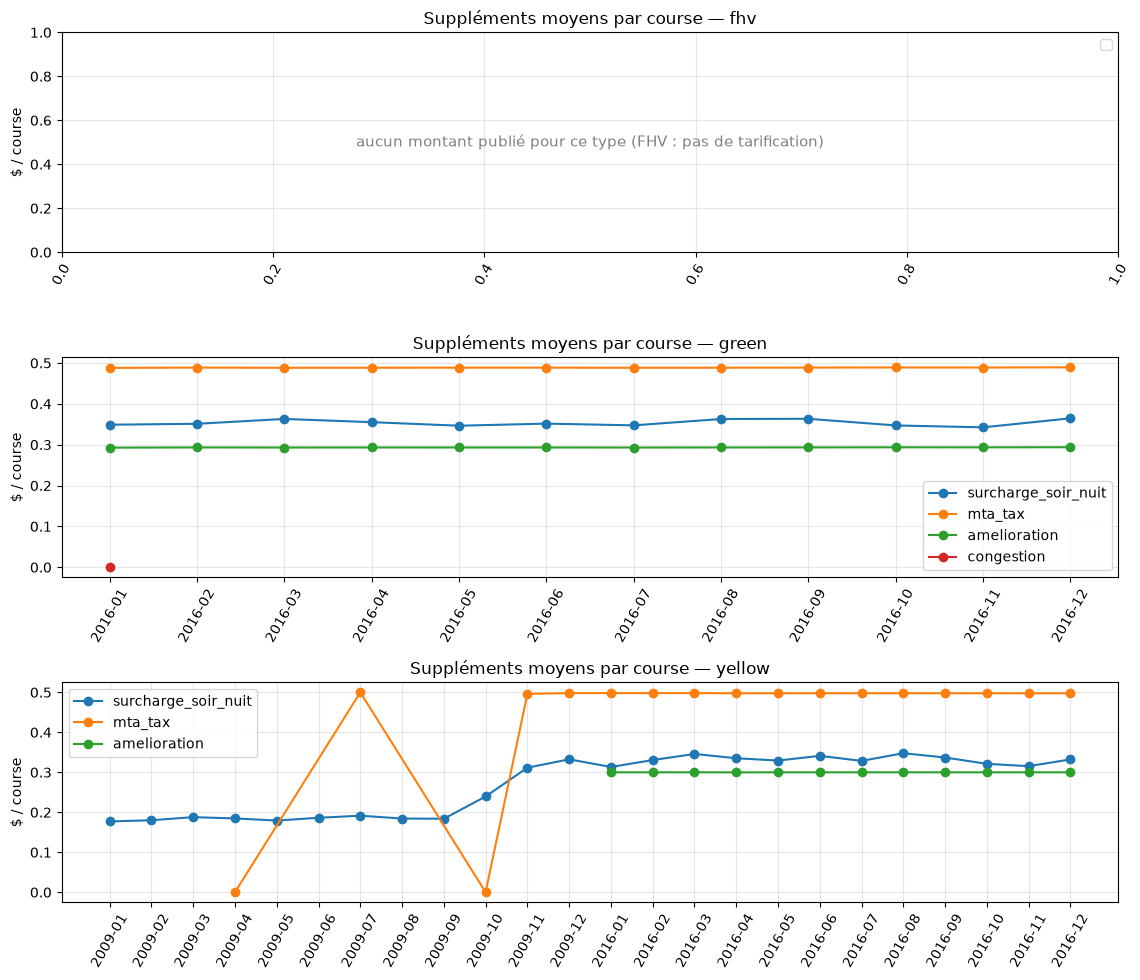

In [2]:
supplements = spark.sql("""
SELECT date_format(pickup_datetime, 'yyyy-MM') AS mois, vtype,
       avg(extra)                 AS surcharge_soir_nuit,
       avg(mta_tax)               AS mta_tax,
       avg(improvement_surcharge) AS amelioration,
       avg(congestion_surcharge)  AS congestion,
       avg(airport_fee)           AS aeroport,
       avg(cbd_convenience_fee)   AS cbd
FROM trips
GROUP BY 1, 2 ORDER BY 1, 2""").toPandas()

vtypes = sorted(supplements["vtype"].unique())
fig, axes = plt.subplots(len(vtypes), 1, figsize=(11.5, 3.3 * len(vtypes)), squeeze=False)
for ax, vt in zip(axes[:, 0], vtypes):
    d = supplements[supplements["vtype"] == vt].set_index("mois").drop(columns="vtype", errors="ignore")
    trace = False
    for col in d.columns:
        s = d[col].dropna()
        if len(s):
            ax.plot(s.index, s.values, marker="o", label=col)
            trace = True
    if not trace:
        ax.text(0.5, 0.5, "aucun montant publié pour ce type (FHV : pas de tarification)",
                ha="center", va="center", transform=ax.transAxes, fontsize=11, color="gray")
    ax.set_title(f"Suppléments moyens par course — {vt}")
    ax.set_ylabel("$ / course")
    ax.grid(alpha=.3)
    ax.legend()
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

## 2. Flux pickup → dropoff entre boroughs (diagramme en corde)

Matrice borough de départ × borough d'arrivée (courses inter-boroughs), rendue en chord diagram
matplotlib. La largeur de chaque ruban est proportionnelle au nombre de courses.

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


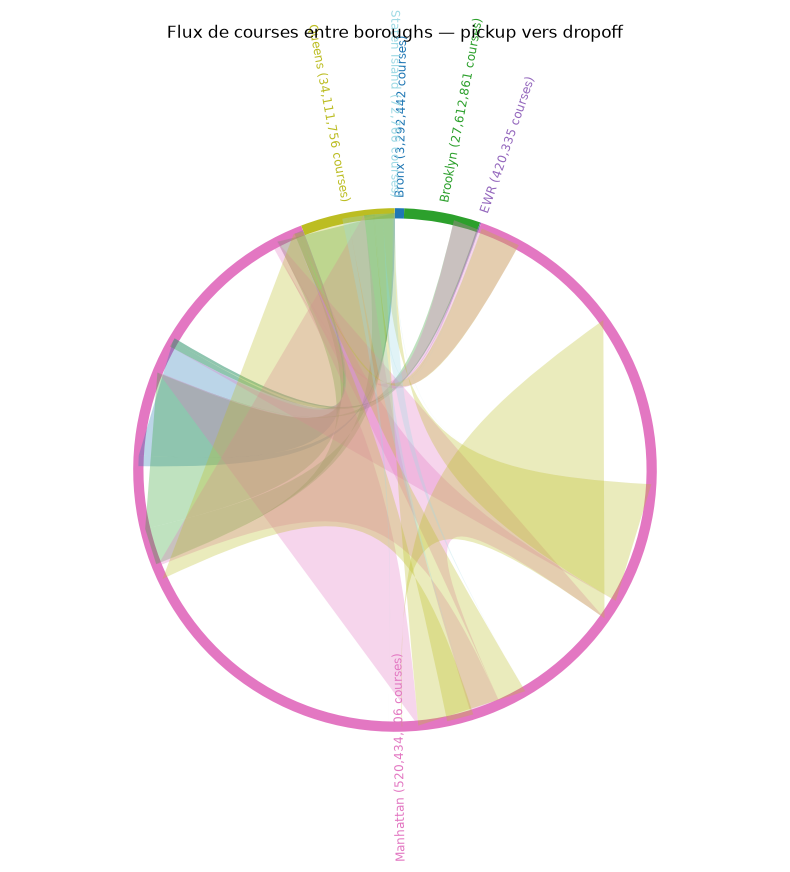

arrivee,Bronx,Brooklyn,EWR,Manhattan,Queens,Staten Island
depart,,,,,,
Bronx,559487,6534,162,245803,21678,111
Brooklyn,19112,6628923,6799,2720864,629812,5387
EWR,9,43,0,374,105,18
Manhattan,1628732,9026820,402177,243850817,9964066,41924
Queens,251303,1938733,10595,8701165,6289839,14358
Staten Island,24,911,53,1147,263,4285


In [3]:
flows = spark.sql("""
SELECT zb.borough AS depart, zd.borough AS arrivee, count(*) AS courses
FROM trips t
JOIN zones zb ON t.pickup_location_id = zb.location_id
JOIN zones zd ON t.dropoff_location_id = zd.location_id
WHERE t.pickup_location_id <> t.dropoff_location_id
GROUP BY 1, 2""").toPandas()

labels = sorted(set(flows["depart"]) | set(flows["arrivee"]))
mat = (flows.pivot(index="depart", columns="arrivee", values="courses")
       .reindex(index=labels, columns=labels).fillna(0.0))

from matplotlib.patches import PathPatch, Wedge
from matplotlib.path import Path

def chord_diagram(mat, title="", unit="courses"):
    labels_ = list(mat.index)
    n = len(labels_)
    flows_v = mat.values.astype(float)
    node_size = flows_v.sum(axis=1) + flows_v.sum(axis=0)
    colors = plt.cm.tab20(np.linspace(0, 1, max(n, 2)))

    fracs = node_size / node_size.sum()
    sect, a = [], 90.0                       # départ à midi, sens horaire
    for f in fracs:
        span = 360.0 * f
        sect.append((a - span, a))
        a -= span

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal"); ax.axis("off")

    def pt(angle_deg, r=1.0):
        t = np.deg2rad(angle_deg)
        return r * np.cos(t), r * np.sin(t)

    for k, ((a0, a1), lab) in enumerate(zip(sect, labels_)):
        ax.add_patch(Wedge((0, 0), 1.02, a0, a1, width=0.04,
                           facecolor=colors[k], edgecolor="none"))
        mid_deg = (a0 + a1) / 2
        mid = np.deg2rad(mid_deg)
        etiquette = f"{lab} ({node_size[k]:,.0f} {unit})"
        if a1 - a0 < 25:                       # secteur étroit => étiquette radiale
            m = mid_deg % 360
            rot, ha = (mid_deg + 180, "right") if 90 < m < 270 else (mid_deg, "left")
            ax.text(1.06 * np.cos(mid), 1.06 * np.sin(mid), etiquette,
                    ha=ha, va="center", rotation=rot, rotation_mode="anchor",
                    fontsize=8.5, color=colors[k])
        else:                                  # gros secteur => étiquette tangentielle
            rot = mid_deg if 0 <= (mid_deg % 360) <= 180 else mid_deg + 180
            ax.text(1.12 * np.cos(mid), 1.12 * np.sin(mid), etiquette,
                    ha="center", va="center", rotation=rot, rotation_mode="anchor",
                    fontsize=8.5, color=colors[k])

    out_cur = {k: sect[k][0] for k in range(n)}
    in_cur = {k: sect[k][0] for k in range(n)}
    K = 0.15                                   # béziers tirés vers le centre
    for i in range(n):
        for j in range(n):
            v = flows_v[i, j]
            if v <= 0:
                continue
            i0, i1 = out_cur[i], out_cur[i] + 360.0 * v / node_size[i]; out_cur[i] = i1
            j0, j1 = in_cur[j], in_cur[j] + 360.0 * v / node_size[j]; in_cur[j] = j1
            if i == j:
                continue                       # flux internes : consommés mais non dessinés
            e0a, e0b, e1a, e1b = pt(i0), pt(i1), pt(j0), pt(j1)
            verts = [e0a,
                     (K * e0a[0], K * e0a[1]), (K * e1a[0], K * e1a[1]), e1a,
                     e1b,
                     (K * e1b[0], K * e1b[1]), (K * e0b[0], K * e0b[1]), e0b,
                     e0a]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax.add_patch(PathPatch(Path(verts, codes),
                                   facecolor=colors[i], alpha=0.30, edgecolor="none"))
    ax.set_title(title, pad=34)
    return ax

chord_diagram(mat, title="Flux de courses entre boroughs — pickup vers dropoff")
plt.show()

mat.astype(int)

## 3. Ridgeline : distribution du prix au km par période, pour une zone de départ

Par défaut : la zone la plus fréquente ; périodes = années si plusieurs années sont ingérées,
sinon mois. Filtres appliqués : distance 0,5–50 km, tarif > 2,50 $ (les courses FHV, sans
montant ni distance, sortent naturellement du périmètre).

+-------------------------+--------+
|zone_name                |c       |
+-------------------------+--------+
|Midtown Center           |10842998|
|Upper East Side South    |10517816|
|Times Sq/Theatre District|9955317 |
|Upper East Side North    |9689647 |
|East Village             |9608778 |
+-------------------------+--------+



C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


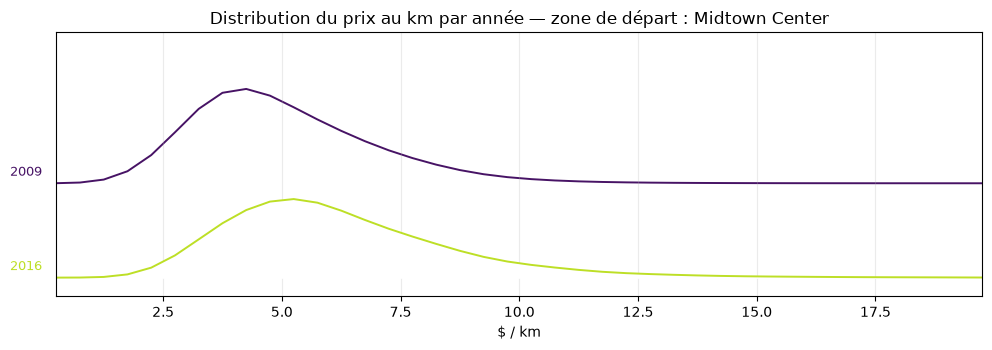

In [4]:
ZONE_DEPART = None   # ex. "Upper East Side South" ; None => zone la plus fréquente

top_zones = spark.sql("""
SELECT z.zone_name, count(*) AS c
FROM trips t JOIN zones z ON t.pickup_location_id = z.location_id
WHERE t.trip_distance BETWEEN 0.5 AND 50 AND t.fare_amount > 2.5
GROUP BY 1 ORDER BY c DESC LIMIT 5""")
top_zones.show(5, False)

zone_name = ZONE_DEPART or top_zones.first()["zone_name"]
loc_id = (spark.read.parquet(str(SILVER / "ref" / "zones.parquet"))
          .where(F.col("zone_name") == zone_name).first()["location_id"])

period_fmt = ("yyyy-MM"
              if spark.sql("SELECT count(DISTINCT year) AS n FROM trips").first()["n"] == 1
              else "yyyy")

hist = spark.sql(f"""
WITH base AS (
    SELECT date_format(pickup_datetime, '{period_fmt}') AS periode,
           fare_amount / trip_distance AS prix_km
    FROM trips
    WHERE pickup_location_id = {int(loc_id)}
      AND trip_distance BETWEEN 0.5 AND 50 AND fare_amount > 2.5
      AND fare_amount / trip_distance < 20
)
SELECT periode, cast(floor(prix_km / 0.5) AS int) AS bin, count(*) AS n
FROM base GROUP BY 1, 2""").toPandas()

BIN_W = 0.5
xs = np.arange(hist["bin"].min(), hist["bin"].max() + 1) * BIN_W + BIN_W / 2
curves = {}
for periode, grp in hist.groupby("periode"):
    dens = np.zeros(len(xs))
    for _, r in grp.iterrows():
        idx = int(round((r["bin"] * BIN_W + BIN_W / 2 - xs[0]) / BIN_W))
        if 0 <= idx < len(dens):
            dens[idx] += r["n"]
    total = dens.sum()
    dens = dens / (total * BIN_W) if total else dens
    kern = np.array([1, 4, 6, 4, 1]) / 16.0
    curves[periode] = np.convolve(np.convolve(dens, kern, "same"), kern, "same")

order = sorted(curves)
fig, ax = plt.subplots(figsize=(10, 1.0 * len(order) + 1.6))
palette = plt.cm.viridis(np.linspace(0.05, 0.9, len(order)))
ymax = max(c.max() for c in curves.values())
for k, periode in enumerate(order):
    base = 1.0 * (len(order) - 1 - k)
    y = curves[periode] / ymax
    ax.fill_between(xs, base, base + y, color="white", zorder=k + 1)
    ax.plot(xs, base + y, color=palette[k], lw=1.4, zorder=k + 1)
    ax.text(xs[0] - 0.3, base + 0.08, periode, ha="right", fontsize=9, color=palette[k])
ax.set_xlim(xs[0], xs[-1]); ax.set_ylim(-0.2, len(order) + 0.6)
ax.set_yticks([])
ax.set_xlabel("$ / km"); ax.grid(alpha=.25, axis="x")
ax.set_title(f"Distribution du prix au km par {'année' if period_fmt == 'yyyy' else 'mois'} "
             f"— zone de départ : {zone_name}")
plt.tight_layout(); plt.show()

## 4. Heatmap jour × heure par type de véhicule

`heatmap_annee(annee)` produit une heatmap (jour de la semaine × heure) des fréquences de
courses, un graphique par type de véhicule ingéré pour cette année.

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


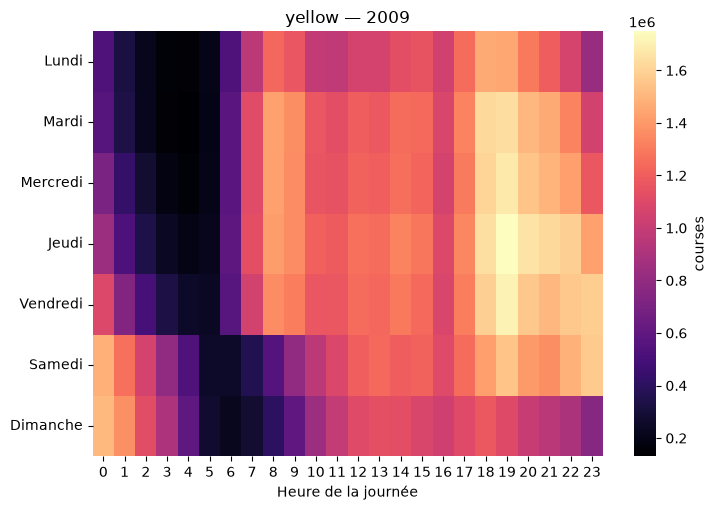

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


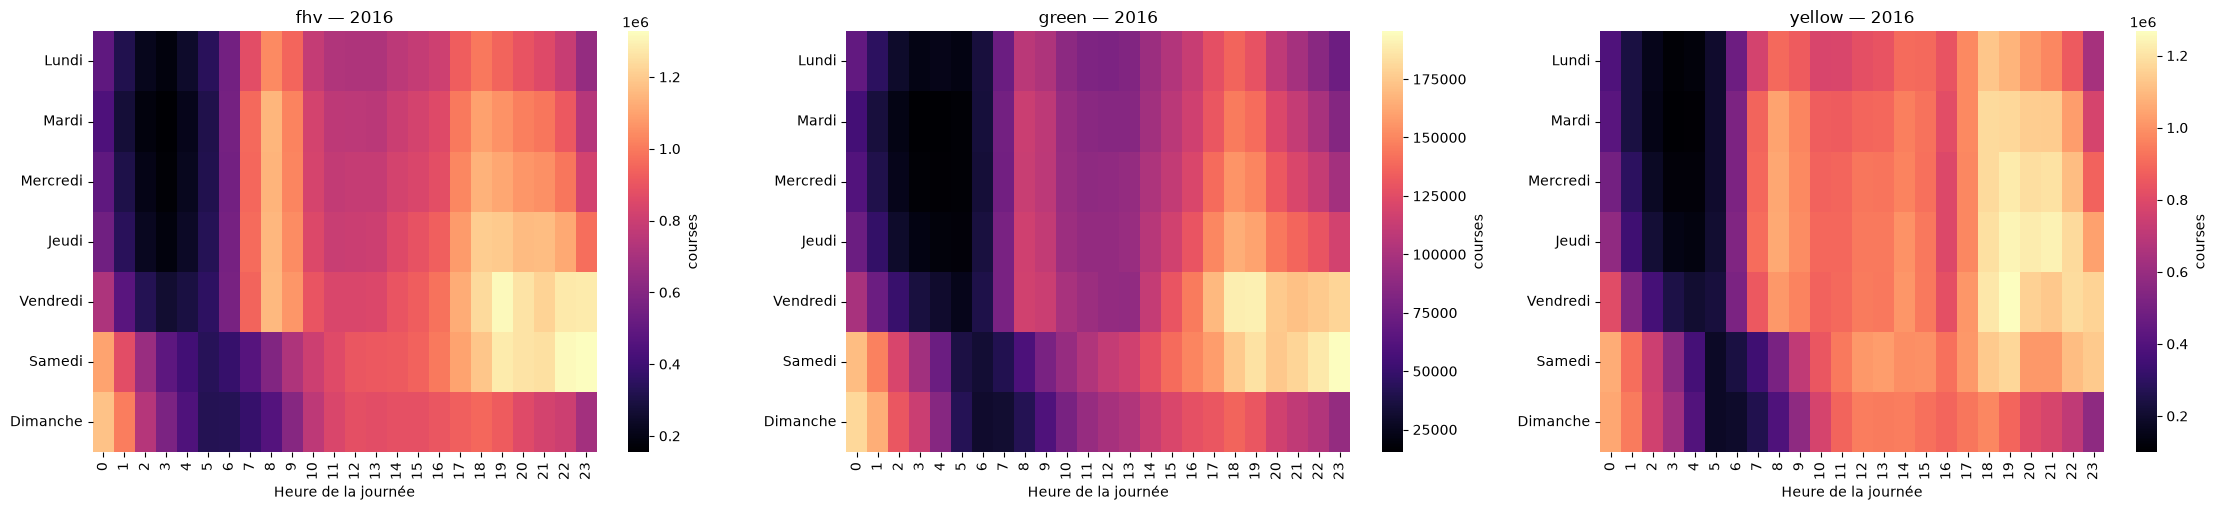

In [5]:
JOURS = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

def heatmap_annee(annee):
    dfh = spark.sql(f"""
    SELECT vtype,
           pmod(dayofweek(pickup_datetime) + 5, 7) AS jour,   -- 0=Lundi ... 6=Dimanche
           hour(pickup_datetime) AS heure,
           count(*) AS courses
    FROM trips
    WHERE year = {annee}
    GROUP BY 1, 2, 3""").toPandas()

    vtypes_ = sorted(dfh["vtype"].unique())
    fig, axes = plt.subplots(1, len(vtypes_), figsize=(7.5 * len(vtypes_), 5.2), squeeze=False)
    for ax_, vt in zip(axes[0], vtypes_):
        piv = (dfh[dfh["vtype"] == vt]
               .pivot(index="jour", columns="heure", values="courses")
               .reindex(index=range(7)).fillna(0))
        sns.heatmap(piv, ax=ax_, cmap="magma", cbar_kws={"label": "courses"})
        ax_.set_title(f"{vt} — {annee}")
        ax_.set_yticklabels(JOURS, rotation=0)
        ax_.set_xlabel("Heure de la journée")
        ax_.set_ylabel("")
    plt.tight_layout(); plt.show()

for annee in sorted(r.vyear for r in spark.sql(
        "SELECT DISTINCT year AS vyear FROM trips ORDER BY vyear").collect()):
    heatmap_annee(annee)

## 5. Écart de prix selon la météo

Prix moyen au km des courses prises en charge sous la pluie (> 0,2 mm/h) contre au sec,
comparé à la moyenne générale. La jointure se fait sur l'heure locale de prise en charge
(météo horaire NYC).

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


conditions   courses  prix_km_moyen  ecart_pct
       sec 271175942       5.069897  -0.124154
     pluie  31344370       5.130838   1.076371

Prix moyen global : 5.076 $/km (302,517,055 courses)


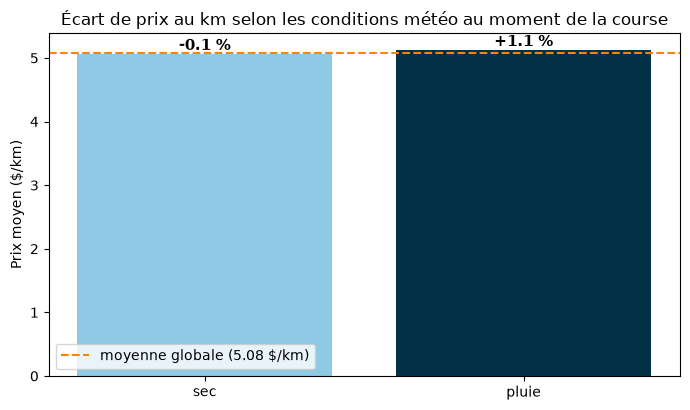

In [6]:
meteo_prix = spark.sql("""
SELECT /*+ BROADCAST(w) */
       CASE WHEN w.precipitation_mm > 0.2 THEN 'pluie' ELSE 'sec' END AS conditions,
       count(*) AS courses,
       avg(t.fare_amount / t.trip_distance) AS prix_km_moyen
FROM trips t
JOIN weather_hourly w ON date_trunc('hour', t.pickup_datetime) = w.ts
WHERE t.trip_distance BETWEEN 0.5 AND 50 AND t.fare_amount > 2.5
GROUP BY 1""").toPandas()

overall = spark.sql("""
SELECT avg(fare_amount / trip_distance) AS m, count(*) AS n
FROM trips WHERE trip_distance BETWEEN 0.5 AND 50 AND fare_amount > 2.5""").first()
moyenne_globale = overall["m"]

meteo_prix["ecart_pct"] = 100 * (meteo_prix["prix_km_moyen"] / moyenne_globale - 1)
print(meteo_prix.to_string(index=False))
print(f"\nPrix moyen global : {moyenne_globale:.3f} $/km ({overall['n']:,} courses)")

fig, ax = plt.subplots(figsize=(7, 4.2))
colors_ = {"sec": "#8ecae6", "pluie": "#023047"}
bars = ax.bar(meteo_prix["conditions"], meteo_prix["prix_km_moyen"],
              color=[colors_.get(c, "gray") for c in meteo_prix["conditions"]])
ax.axhline(moyenne_globale, color="#fb8500", ls="--", lw=1.5,
           label=f"moyenne globale ({moyenne_globale:.2f} $/km)")
for b, ecart in zip(bars, meteo_prix["ecart_pct"]):
    ax.annotate(f"{ecart:+.1f} %", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Prix moyen ($/km)")
ax.set_title("Écart de prix au km selon les conditions météo au moment de la course")
ax.legend()
plt.tight_layout(); plt.show()

## Synthèse

| Insight | Lecture |
|---|---|
| Suppléments | chaque taxe apparaît à sa date réglementaire ; FHV ne publie aucun montant |
| Flux | Manhattan concentre l'écrasante majorité des flux inter-boroughs |
| Prix/km | la distribution se resserre autour de ~4 $/km ; dérive visible entre années |
| Rythme | pics 18–19 h en semaine ; week-ends décalés après minuit |
| Météo | rouler sous la pluie coûte ~2 % de plus au km |